# Class 24: Fourier Transforms Part 2

Ch. 7, section 4: Fast Fourier Transforms 

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [2]:
import numpy as np
from numpy import fft
import matplotlib.pyplot as plt
import time
import cmath
import random

### Fast Fourier Transforms 

**Super Simple Example:** Calculate FFT of a simple sawtooth example and then the inverse FFT

[ 4.5+0.j         -0.5+1.53884177j -0.5+0.68819096j -0.5+0.36327126j
 -0.5+0.16245985j -0.5+0.j        ]


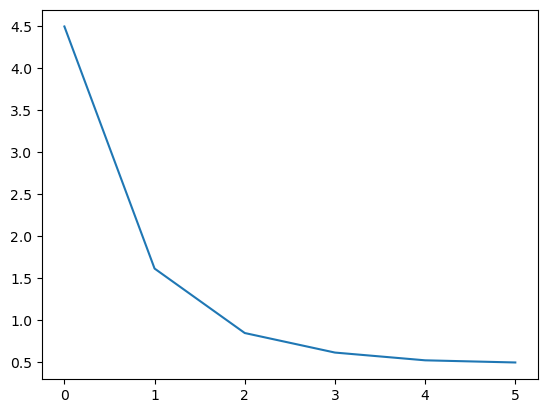

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [ ]:
y = np.array([0.,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], float)
c = fft.rfft(y)

print(c)

plt.plot(np.abs(c))
plt.show()

z = fft.irfft(c)

print(z)

#### Discrete Fourier transform function from previous class

In [10]:
def DFT(y): 
    # determine the number of sample points
    N = len(y)
    # create array for fourier coefficients 
    c = np.zeros(N//2+1, complex)
    # loop through to calculate coefficients 
    for k in range(N//2+1): 
        for n in range(N):
            c[k] += y[n]*cmath.exp(-2j*np.pi*k*n/N)
    return c

In [12]:
c_DFT = DFT(y)

print(c_DFT)
print(c)


[ 4.5+0.00000000e+00j -0.5+1.53884177e+00j -0.5+6.88190960e-01j
 -0.5+3.63271264e-01j -0.5+1.62459848e-01j -0.5-5.51091060e-16j]
[ 4.5+0.j         -0.5+1.53884177j -0.5+0.68819096j -0.5+0.36327126j
 -0.5+0.16245985j -0.5+0.j        ]


### Exercise 7.3: Fourier transforms of the sound of musical instruments

In the on-line resources you will find files called `piano.txt` and `trumpet.txt`, which contain data representing the waveform of a single note, played on, respectively, a piano and a trumpet.

**a)** Write a program that loads a waveform from one of these files, plots it, then calculates its discrete Fourier transform and plots the magnitudes of the first 10,000 coefficients in a manner similar to Fig. 7.3. Note that you will have to use a fast Fourier transform for the calculation because there are too many samples in the files to do the transforms the slow way in any reasonable amount of time.

Apply your program to the piano and trumpet waveforms and discuss briefly what one can conclude about the sound of the piano and trumpet from the plots of Fourier coefficients.

[ 37.  36.  34. ... 246. 262. 275.]


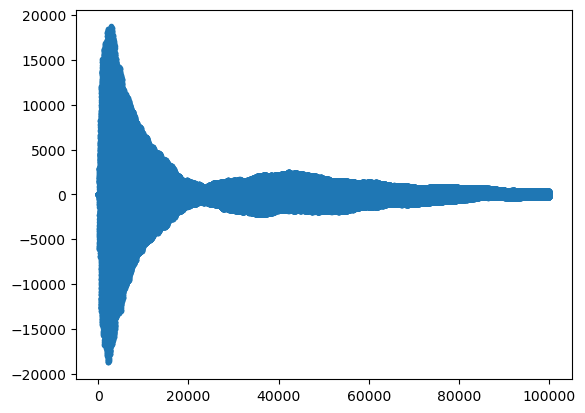

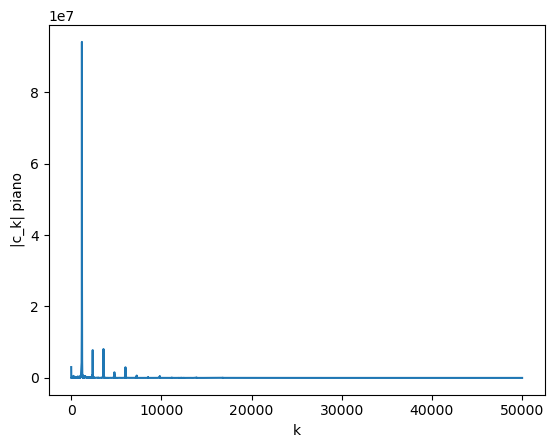

In [15]:
# Read in the data from piano.txt
data_p = np.loadtxt("piano.txt", float)
print(data_p)
plt.figure(1)
plt.plot(data_p, ".")
plt.show()

# Take the FFT of the data
c_piano = fft.rfft(data_p)

#Plot the coefficients
plt.figure(2)
plt.plot(np.abs(c_piano))
plt.xlabel("k")
plt.ylabel("|c_k| piano")
plt.show()

[-2.000e+00 -5.000e+00 -1.000e+00 ...  4.225e+03  4.414e+03  4.397e+03]


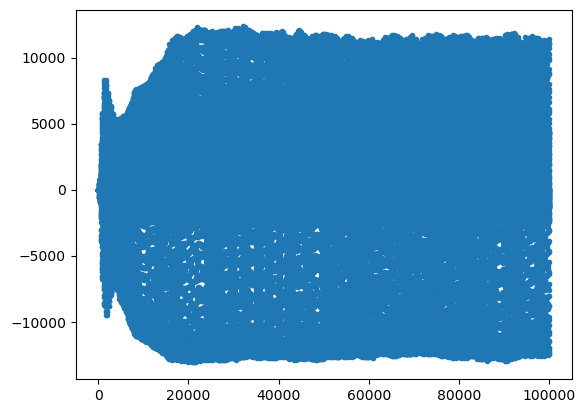

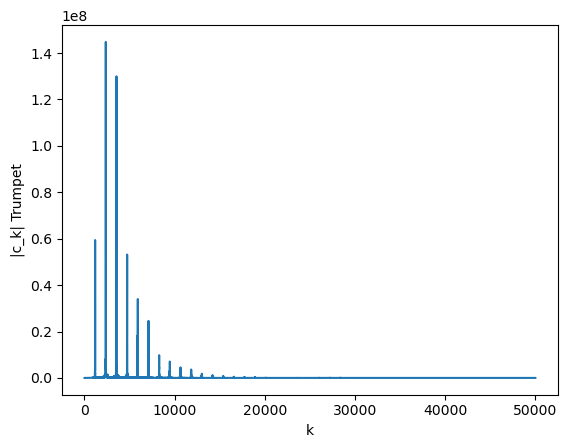

In [17]:
# Read in the data from piano.txt
data_t = np.loadtxt("trumpet.txt", float)
print(data_t)
plt.figure(1)
plt.plot(data_t, ".")
plt.show()

# Take the FFT of the data
c_tr = fft.rfft(data_t)

#Plot the coefficients
plt.figure(2)
plt.plot(np.abs(c_tr))
plt.xlabel("k")
plt.ylabel("|c_k| Trumpet")
plt.show()

**b)** Both waveforms were recorded at the industry-standard rate of 44,100 samples per second and both instruments were playing the same musical note when the recordings were made. From your Fourier transform results calculate what note they were playing. (Hint 1: the musical notes corresonds to the first peak int ehs pectrum, which is not necessarily the highest peak. Hint 2: The musical note middle C has a frequency of 261.6 Hz.)

In [22]:
# find k value for piano for fundamental
kp_fund = np.argmax(np.abs(c_piano))
print(kp_fund)

# find k value for piano for fundamental
kt_fund = np.argmax(np.abs(c_tr[0:2000]))
print(kt_fund)

Np = len(data_p)
Nt = len(data_t)
nu = 44100 #samples per seconds 
freq_fund_p = kp_fund*nu/Np
freq_fund_t = kt_fund*nu/Nt

print(freq_fund_p, freq_fund_t)

1190
1183
524.79 521.703
